## 0. Crucial imports

In [233]:
import webdataset as wds
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
from torchvision import transforms
if torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'cpu'
torch.cuda.is_available()


True

# 1. Data Preparation

### 1.1 Read data to dataframme 
- Reading data to pandas dataframe 
- Making Dataframe searchable by 'name.png' by changing ID from integers to name of the image

In [234]:
df = pd.read_csv("Data_Entry_2017.csv")
df = df.set_index('Image Index')
print(df.head(3))


                          Finding Labels  Follow-up #  Patient ID Patient Age  \
Image Index                                                                     
00000001_000.png            Cardiomegaly            0           1        058Y   
00000001_001.png  Cardiomegaly|Emphysema            1           1        058Y   
00000001_002.png   Cardiomegaly|Effusion            2           1        058Y   

                 Patient Gender View Position  OriginalImage[Width  Height]  \
Image Index                                                                   
00000001_000.png              M            PA                 2682     2749   
00000001_001.png              M            PA                 2894     2729   
00000001_002.png              M            PA                 2500     2048   

                  OriginalImagePixelSpacing[x     y]  Unnamed: 11  
Image Index                                                        
00000001_000.png                        0.143  0.143          

### 1.2 Encode labels to vector
* Introduce label encoding (not one-hot because of multilabel instances)
* Introduce function returning labels from vector

In [235]:
all_labels = [
    "No Finding", "Atelectasis", "Consolidation", "Infiltration", 
    "Pneumothorax", "Edema", "Emphysema", "Fibrosis", "Effusion", 
    "Pneumonia", "Pleural_Thickening", "Cardiomegaly", "Nodule", "Mass", "Hernia"
]
label_to_idx = {label:i for i, label in enumerate(all_labels)}

def encode_label(label):
    vector_labels = torch.zeros(len(all_labels), dtype=torch.float32)
    
    if not isinstance(label, str): #handling NaN or empty
        return vector_labels
    
    labels = label.split("|")
    for l in labels:
        if l not in label_to_idx: #handling inproper names of diseases
            continue
        vector_labels[label_to_idx[l]] = 1.0

    return vector_labels

def vector_idx_to_labels(vector_idx):
    return [label for label, val in zip(all_labels, vector_idx) if val > 0.5]

### 1.3 Pipeline for random sample

Taking all images in batches of 1000, shuffling them, converting to PyTorchRGB tensors from 12 tar files and returning for it:
* image_data = data of each pixel of each photo
* label = name of the disease

In [236]:
def process_sample(sample):

    image_data = sample['png']
    full_key = sample["__key__"]
    clean_key = full_key.replace("images/", "") + ".png"
    vector_label = encode_label(df.at[clean_key, 'Finding Labels'])

    return image_data, vector_label


url = "images/images_{001..012}.tar.gz"
dataset = (
    wds.WebDataset(url,shardshuffle=False)
    .shuffle(1000)
    .decode("torchrgb")
    .map(process_sample)
)

for (image, vector_label) in dataset:
    print(f" image shape={image.shape}, labels={vector_idx_to_labels(vector_label)}")
    break

 image shape=torch.Size([3, 1024, 1024]), labels=['No Finding']


### 1.4 Displaying three random images from sample

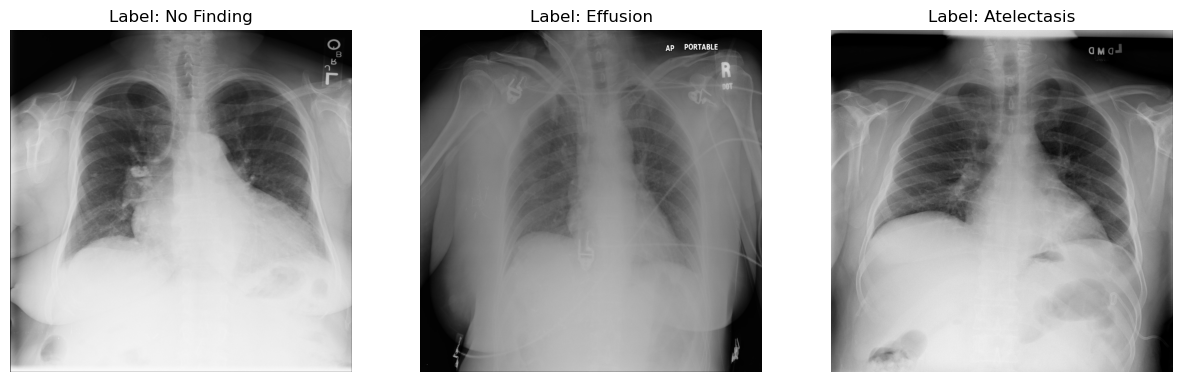

In [237]:

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sample_iter = iter(dataset)

for i in range(3):
    image_tensor, label = next(sample_iter)
    img = image_tensor.permute(1, 2, 0).numpy()

    axes[i].imshow(img)
    label_text = ", ".join(vector_idx_to_labels(label))
    axes[i].set_title(f"Label: {label_text}")
    axes[i].axis('off')

plt.show()

### 1.5 Shuffling csv file for randomness

In [238]:
torch.cuda.manual_seed(67)

shuffled_df = df.sample(frac=1)
print(shuffled_df.head(1))

                 Finding Labels  Follow-up #  Patient ID Patient Age  \
Image Index                                                            
00016086_001.png           Mass            1       16086        060Y   

                 Patient Gender View Position  OriginalImage[Width  Height]  \
Image Index                                                                   
00016086_001.png              M            AP                 2500     2048   

                  OriginalImagePixelSpacing[x     y]  Unnamed: 11  
Image Index                                                        
00016086_001.png                        0.168  0.168          NaN  


### 1.6 Splitting data into training and validation

In [239]:
population_size = len(df)
train_split = int(0.8*population_size)

train_df = shuffled_df[:train_split]
val_df = shuffled_df[train_split:]

len(shuffled_df), len(train_df), len(val_df)

(112120, 89696, 22424)

### 1.7 Introducing raw datasets for train and validation
use `for (image, label) in train_dataset` and `vector_idx_to_labels(image)` to loop over it

In [240]:
train_dataset = (
    wds.WebDataset(url, shardshuffle=676767)
    .select(lambda x: (x["__key__"].replace("images/", "") + ".png") in train_df.index)
    .shuffle(1000)
    .decode("torchrgb")
    .map(process_sample)
)

val_dataset = (
    wds.WebDataset(url, shardshuffle=False) 
    .select(lambda x: (x["__key__"].replace("images/", "") + ".png") in val_df.index)
    .decode("torchrgb")
    .map(process_sample)
)

### 1.8 Data Tranformation
Data in AlexNet must be in correct format: 

--ALEXNET NOT MADE FOR MULTILABELS!!!--

* shape 3xHxW and H and W must be at least 224 (already satisfied)
* mean and std must be in correct range

In [241]:
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.255])
])

stream = iter(train_dataset)
sample_image,sample_label = next(stream)

input_tensor = preprocess(sample_image)
input_batch = input_tensor.unsqueeze(0)

input_batch = input_batch.to(device)

print(input_batch.shape)
print(vector_idx_to_labels(sample_label))
print(input_batch.device)

torch.Size([1, 3, 224, 224])
['Consolidation', 'Edema']
cuda:0
